# PyToch Convolutional Neural Network Training

-   If use google collaborant, run inside yolo_mps_v11

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

import matplotlib.pyplot as plt
import numpy as np

import copy

print("imports ok!")

imports ok!


In [2]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")          # Apple Silicon GPU
    elif torch.cuda.is_available():
        return torch.device("cuda")         # NVIDIA GPU
    else:
        return torch.device("cpu")          # Fallback

device = get_device()
print("Using device:", device)

Using device: cpu


## Formula to calculate output size
__(N+F+2P) / S+1__ where:
-   N = activation size (incoming input size)
-   F = kernel
-   S = strike
-   P = padding

Calculation of volumes:
- Convolution1: 
    - no padding, stride 1
    - input = 32
    - kernel = 5
    - spatial size = ((32 - 5 + 0)/1) + 1 = 28
    - output = output channels x spatial size^2 
    - output = (6 x 28 x 28)

- Max pool (2x2)
    - input = 28
    - Spatial size =(28/2 = 14)
    - output = output channels x spatial size^2 
    - output (6 x 14 x 14)

- Convolution 2: 
    - no padding, stride 1
    - Spatial size = ((14-5+0)/1)+1 = 10
    - output = output channels x spatial size^2 
    - output (16 x 10 x 10)

- Max pool (2x2)
    - input = 10
    - Spatial size = (10 / 2 = 5)
    - output (16 x 5 x 5)
  
- Flatten
    - 16 x 5 x 5 = 400 input to fully connected layer

In [3]:
# define neural network
class Net(nn.Module):
    def __init__(self, grayscale=False):
        super(Net, self).__init__() # constructor

        # first layer is CNN
        self.grayscale = grayscale
        if grayscale:
            # Input image 32x32x1, 6 output channels, 5x5 convolution
            self.conv1 = nn.Conv2d(1, 6, 5)
        else:
            # Input image 32x32x3, 6 output channels, 5x5 convolution
            self.conv1 = nn.Conv2d(3, 6, 5)

        # second layer is CNN
        # params: in-channels, out-channels, kernel-size
        self.conv2 = nn.Conv2d(6, 16, 5)

        # final layer3 are fully connected ANN (not CNN)
        self.fc1 = nn.Linear( 16 * 5 * 5, 120)
        self.fc2 = nn.Linear( 120, 84)
        self.fc3 = nn.Linear( 84, 10)

    # define forward callback function
    def forward(self, x):
        # conv layer c1: 
        #       1/3 input image channels,
        #       6 output channels
        #       5x5 kernel, ReLu
        #       outputs: Tensor (N, 6, 28, 28)
        #       N means batch size, needed because we do not update weights 
        #       all the time but after a batch
        cv1 = F.relu(self.conv1(x))

        # sumbsampling layer ss2: 
        # 2x2 grid, stride 2
        # subsampling => reduce size of activation map
        # outputs: (N, 6, 14, 14)
        # where N = batch, 6 = layers, 14 = x, 14 = y
        ss2 = F.max_pool2d(cv1, (2,2))

        # convolution layer C3: 
        # 6 input channels, 16 output channels
        # 5x5 kernel, ReLU
        # outputs: (N, 16, 10, 10)
        cv3 = F.relu(self.conv2(ss2))

        # Subsampling layer SS4: 
        # 2x2 grid, stride 2
        # subsampling => reduce size of activation map
        # outputs: (N, 16, 5, 5)
        ss4 = F.max_pool2d(cv3, (2,2))

        # flatten (16 * 5 * 5) = 400
        ss4f = torch.flatten(ss4, 1)

        # Fully connected layer FC5:
        # inputs (N, 400) 
        # outputs: (N, 120) with ReLu
        fcl5 = F.relu(self.fc1(ss4f))

        # Fully connected layer FCL6: 
        # inputs (N, 120) with ReLu
        # outputs (N, 84) with ReLu
        fcl6 = F.relu(self.fc2(fcl5))

        # Fully connected layer FCL6
        # inputs (N, 120) with ReLu
        # outputs (N, 84) with ReLu
        fcl6 = F.relu(self.fc2(fcl5))

        # Fully connected layer FCL7
        # inputs (N, 120) with ReLu
        # outputs (N, 10)
        fcl7 = self.fc3(fcl6)

        return fcl7

# Create CNN network with GPU
net = Net().to(device)
print(f"{net} using {device}")


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
) using cpu


In [4]:
# initialize dataloaders is the data pipeline
def InitializeDataLoaders(batch_size=4, model_save_path='./data', grayscale=False):
    # Crete pipeline using Compose
    if grayscale:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # we need to verify that gray image is not 3 channels that just looks gray
            # but a real 1 channel gray image
            transforms.Grayscale(num_output_channels=1),
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # scale values [-1, 1] with mean 0
            transforms.Normalize
        ])
    else:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # three channels, so make pixels from [0,1] to [-1, 1]
            # x' = ((x-0.5)/0.5)
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    # batch size = 4
    # each iteration over trainloader yields a batch of 4 images + labels
    # => model sees 4 samples at a time, 
    #       the loss/gradients are computed over those 4
    #       then one optimizer step is taken
    trainset = torchvision.datasets.CIFAR10(
        root=model_save_path, 
        train=True, 
        download=True,
        transform=transform)
    
    # remember to shuffle train set data every batch or NN learns the order of images
    trainloader = torch.utils.data.DataLoader(
        trainset, 
        batch_size=batch_size,
        shuffle=True,
        num_workers=2)
    
    # TEST SETS
    testset = torchvision.datasets.CIFAR10(
        root=model_save_path, 
        train=False, 
        download=True,
        transform=transform)
    
    # test data no need shuffle, no matter
    testloader = torch.utils.data.DataLoader(
        trainset, 
        batch_size=batch_size,
        shuffle=False,
        num_workers=2)
    
    return trainloader, testloader

In [5]:
# initialize dataloaders is the data pipeline with validation
# this is optional to be used instead of normal InitializeDataLoaders()
def InitializeDataLoadersWithValidation(
        batch_size=4, 
        data_root='./data', 
        val_fraction=0.1, 
        grayscale=False
    ):
    # Create pipeline using Compose
    if grayscale:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # we need to verify that gray image is not 3 channels that just looks gray
            # but a real 1 channel gray image
            transforms.Grayscale(num_output_channels=1),
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # scale values [-1, 1] with mean 0
            transforms.Normalize
        ])
    else:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # three channels, so make pixels from [0,1] to [-1, 1]
            # x' = ((x-0.5)/0.5)
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    
    full_train = torchvision.datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform)

    # Split train → (train + val)
    val_size = int(len(full_train) * val_fraction)
    train_size = len(full_train) - val_size
    train_set, val_set = random_split(full_train, [train_size, val_size])

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    valloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, valloader, testloader

In [6]:
# detectable objects are classified
def DefineClasses():
  classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
  return classes

In [7]:
def TrainNetwork(net, epoch_count, trainloader, optimizer, criterion, device=device):
    history = {
        "epoch_loss": [],
        "epoch_accuracy": []
    }

    best_accuracy = 0.0
    # return state of neural network with dictionary
    best_state_dict = copy.deepcopy(net.state_dict())
    best_epoch = -1

    for epoch in range(epoch_count):
        net.train()

        running_loss = 0.0
        epoch_loss_sum = 0.0
        correct = 0
        total = 0

        # iterate over epoch
        # output: 4x1x32x32 if batch_size=4, grayscale image of 32x32
        # means 4 images per batch, and then run the training
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device) # name of object type

            optimizer.zero_grad() # clean gradients before backpropagation

            # forward + backward + optimize
            outputs = net(inputs) # net() calls forward automatically, forward does gradient stuff automatically
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # statistics
            batch_loss = loss.item()
            running_loss += batch_loss
            epoch_loss_sum += batch_loss

            # accumulate  accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # was prediction correct or not

            if (i % 2000) ==  1999:
                print(f"Epoch {epoch + 1} batch {i + 1} loss (last 2000 batches): {running_loss/2000:.4f}")
                running_loss = 0.0

        # epoch statistics
        epoch_loss = epoch_loss_sum / max(1, len(trainloader))
        epoch_accuracy = correct / total if total > 0 else 0.0

        history["epoch_loss"].append(epoch_loss)
        history["epoch_accuracy"].append(epoch_accuracy)

        # track best model
        if (epoch_accuracy > best_accuracy):
            best_accuracy = epoch_accuracy
            # return state of neural network with dictionary
            best_state_dict = copy.deepcopy(net.state_dict())
            best_epoch = epoch

        print(f"Epoch {epoch + 1} / {epoch_count}")
        print(f"loss: {epoch_loss:.4f}")
        print(f"accuracy: {epoch_accuracy:.4f}")
        print(f"best so far: {best_epoch}")

    print("Finished training!")
    return history, best_state_dict, best_epoch

In [ ]:
def TrainNetworkWithValidation(net, nbr_of_epochs, trainloader, valloader, optimizer, criterion, device=device):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss":   [],
        "val_acc":    [],
    }

    best_val_loss = float('inf')
    best_state_dict = copy.deepcopy(net.state_dict())
    best_epoch = -1

    for epoch in range(nbr_of_epochs):
        # ----------------------
        # 1) TRAINING PHASE
        # ----------------------
        net.train()  # important: training mode

        running_loss_batch = 0.0
        epoch_loss_sum = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(trainloader, 0):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # clean gradients before backpropagation

            # forward+backward+optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # stats
            batch_loss = loss.item()
            running_loss_batch += batch_loss
            epoch_loss_sum += batch_loss

            # accumulate accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            if i % 2000 == 1999:
                print(f'[Epoch: {epoch+1} batch:{i+1}] '
                        f'train batch loss: {running_loss_batch/2000:.4f}')
                running_loss_batch = 0.0

        # epoch-level training stats
        train_epoch_loss = epoch_loss_sum / max(1, len(trainloader))
        train_epoch_acc = correct_train / total_train if total_train > 0 else 0.0

        history["train_loss"].append(train_epoch_loss)
        history["train_acc"].append(train_epoch_acc)

        # ----------------------
        # 2) VALIDATION PHASE
        # ----------------------
        net.eval()  # evaluation mode
        val_loss_sum = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in valloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = net(inputs)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_epoch_loss = val_loss_sum / max(1, len(valloader))
        val_epoch_acc = correct_val / total_val if total_val > 0 else 0.0

        history["val_loss"].append(val_epoch_loss)
        history["val_acc"].append(val_epoch_acc)

        # ----------------------
        # 3) TRACK BEST MODEL (by VAL LOSS)
        # ----------------------
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_state_dict = copy.deepcopy(net.state_dict())
            best_epoch = epoch

        print(
            f'Epoch {epoch+1}/{nbr_of_epochs} '
            f'--> train_loss: {train_epoch_loss:.4f}, train_acc: {train_epoch_acc*100:.2f}% | '
            f'val_loss: {val_epoch_loss:.4f}, val_acc: {val_epoch_acc*100:.2f}% '
            f'(best val_loss at epoch {best_epoch+1}, {best_val_loss:.4f})'
        )

    print('Finished training.')

    return history, best_state_dict, best_epoch, epoch


In [9]:
# implement early stopping in training
# min mode = validation loss decreases
# max mode = validation accuracy increases
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0, mode="min"):
        """
        mode="min": monitored value should decrease (e.g., val_loss)
        mode="max": monitored value should increase (e.g., val_acc)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best = None
        self.num_bad_epochs = 0
        self.best_state_dict = None
        self.best_epoch = -1

    def _is_improvement(self, value: float) -> bool:
        if self.best is None:
            return True
        if self.mode == "min":
            return value < (self.best - self.min_delta)
        else:
            return value > (self.best + self.min_delta)
        
    def step(self, value: float, model, epoch: int) -> bool:
        """
        Returns True if training should stop.
        """
        if self._is_improvement(value):
            self.best = value
            self.num_bad_epochs = 0
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch
            return False
        else:
            self.num_bad_epochs += 1
            return self.num_bad_epochs >= self.patience

In [ ]:
def TrainNetworkWithValidationAndEarlyStopping(
    net,
    nbr_of_epochs,
    trainloader,
    valloader,
    optimizer,
    criterion,
    device=device,
    early_patience=7,
    early_min_delta=1e-3,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss":   [],
        "val_acc":    [],
    }

    # Early stopping monitors val_loss (minimize)
    early = EarlyStopping(patience=early_patience, min_delta=early_min_delta, mode="min")

    for epoch in range(nbr_of_epochs):
        # ----------------------
        # 1) TRAINING PHASE
        # ----------------------
        net.train()

        running_loss_batch = 0.0
        epoch_loss_sum = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(trainloader, 0):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # clean gradients before backpropagation

            # forward+backward+optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # stats
            batch_loss = loss.item()
            running_loss_batch += batch_loss
            epoch_loss_sum += batch_loss

            # accumulate accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            if i % 2000 == 1999:
                print(f'[Epoch: {epoch+1} batch:{i+1}] '
                      f'train batch loss: {running_loss_batch/2000:.4f}')
                running_loss_batch = 0.0

        # epoch-level training stats
        train_epoch_loss = epoch_loss_sum / max(1, len(trainloader))
        train_epoch_acc = correct_train / total_train if total_train > 0 else 0.0

        history["train_loss"].append(train_epoch_loss)
        history["train_acc"].append(train_epoch_acc)

        # ----------------------
        # 2) VALIDATION PHASE
        # ----------------------
        net.eval()
        val_loss_sum = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in valloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_epoch_loss = val_loss_sum / max(1, len(valloader))
        val_epoch_acc = correct_val / total_val if total_val > 0 else 0.0

        history["val_loss"].append(val_epoch_loss)
        history["val_acc"].append(val_epoch_acc)

        # ----------------------
        # 3) EARLY STOPPING (tracks best + decides stop)
        # ----------------------
        should_stop = early.step(val_epoch_loss, net, epoch)

        print(
            f'Epoch {epoch+1}/{nbr_of_epochs} '
            f'--> train_loss: {train_epoch_loss:.4f}, train_acc: {train_epoch_acc*100:.2f}% | '
            f'val_loss: {val_epoch_loss:.4f}, val_acc: {val_epoch_acc*100:.2f}% '
            f'(best val_loss at epoch {early.best_epoch+1}, {early.best:.4f})'
        )

        if should_stop:
            print(
                f"Early stopping triggered at epoch {epoch+1}. "
                f"Best val_loss was {early.best:.4f} at epoch {early.best_epoch+1}."
            )
            break

    print('Finished training.')

    # Return the best model snapshot (like before)
    best_state_dict = early.best_state_dict if early.best_state_dict is not None else copy.deepcopy(net.state_dict())
    best_epoch = early.best_epoch

    return history, best_state_dict, best_epoch, epoch


In [11]:
def SaveNetworkModel(net, path):
  torch.save(net.state_dict(), path)

In [12]:
# ---- visualize learning curves ----
def VisualizeLearningCurves(history, nbr_of_epochs):
  epochs = range(1, nbr_of_epochs + 1)

  plt.figure(figsize=(10, 4))

  # Loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["epoch_loss"], marker='o')
  plt.title("Training Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.grid(True)

  # Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, [acc * 100 for acc in history["epoch_accuracy"]], marker='o')
  plt.title("Training Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy (%)")
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [13]:
# ---- visualize learning curves (train + val) ----
def VisualizeLearningCurvesWithValidation(history, nbr_of_epochs: int) -> None:
    epochs = range(1, nbr_of_epochs + 1)

    plt.figure(figsize=(10, 4))

    # ----- Loss: train vs val -----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="Train loss")
    plt.plot(epochs, history["val_loss"],   marker='s', label="Val loss")
    plt.title("Loss per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # ----- Accuracy: train vs val -----
    plt.subplot(1, 2, 2)
    plt.plot(
        epochs,
        [acc * 100 for acc in history["train_acc"]],
        marker='o',
        label="Train acc"
    )
    plt.plot(
        epochs,
        [acc * 100 for acc in history["val_acc"]],
        marker='s',
        label="Val acc"
    )
    plt.title("Accuracy per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [14]:
def ImgShow(img):
    img = img / 2 + 0.5 # denormalize 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

def ImgShowGrid(loader, classes, batch_size):
    dataiter = iter(loader)
    # next is python inbuilt function, gets next object from iterator
    images, labels = next(dataiter)

    ImgShow(torchvision.utils.make_grid(images))

    print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [15]:
def TrainAndSaveModel(
                epoch_count=4, 
                batch_size=4, 
                save_path="./cifar_net.pth", 
                save_best=True,
                device=device):
    # CREATE THE NETWORK THAT IS USED FOR TRAINING CNN
    cnn = Net() 
    cnn.to(device)

    print('Initializing dataloaders')
    trainloader, testloader = InitializeDataLoaders(batch_size)
    classes = DefineClasses()
    print('...classes defined')

    criterion = nn.CrossEntropyLoss()
    # stocastic variant decent for optimizer
    optimizer = optim.SGD(cnn.parameters(), lr=0.001, momentum=0.9)

    print("...criterion and optimizer defined about to train")
    history, best_state_dict, best_epoch = TrainNetwork(cnn, epoch_count, trainloader, optimizer, criterion, device)

    # always saves path
    if save_path != None:
        # save best model, despite what last model was, so model does not overtrain
        if save_best:
            cnn.load_state_dict(best_state_dict)
            cnn.to(device)

            print(f"saving best model {best_epoch + 1}")
        # very situational: save last model even if overtrained
        else:
            print("saving last model")

        # save trained model to harddrive
        SaveNetworkModel(cnn, save_path)

    VisualizeLearningCurves(history, epoch_count)
    return cnn, classes, trainloader, testloader, history

In [ ]:
def TrainAndSaveModelWithValidation(nbr_of_epochs=4, batch_size=4, save_path='./cifar_net_best.pth',device=device):
    cnn = Net()
    cnn.to(device)

    print('Initializing DataLoaders...')
    trainloader, valloader, testloader = InitializeDataLoadersWithValidation(
        batch_size=batch_size,
        data_root='./data',
        grayscale=False,          
    )
    classes = DefineClasses()
    print('...classes defined')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(cnn.parameters(), lr=0.001, momentum=0.9)
    print('...criterion and optimizer defined')

    # MODIFY THIS TO SUPPORT LR adaption
    opModes = ['WithValidation', 'WithValidationAndEarlyStopping','WithValidationAndEarlyStoppingPlusLRAdaption']
    opModeIdx = 1
    opMode = opModes[opModeIdx]

    if opMode == 'WithValidation':
        print('...about to train the network (with validation)')
        history, best_state_dict, best_epoch, true_epochs = TrainNetworkWithValidation(cnn, nbr_of_epochs, trainloader, valloader, optimizer, criterion, device)
    elif opMode == 'WithValidationAndEarlyStopping':
        print('...about to train the network (with validation and Early stopping)')
        history, best_state_dict, best_epoch, true_epochs = TrainNetworkWithValidationAndEarlyStopping(cnn, nbr_of_epochs, trainloader, valloader, optimizer, criterion, device, 
            early_patience=7, early_min_delta=1e-3)
    elif opMode == 'WithValidationAndEarlyStoppingPlusLRAdaption':
        print('...about to train the network (with validation and Early stopping including LR adaption)')
        # LR Adaption = Learning Rate Adaption
        history, best_state_dict, best_epoch, true_epochs = TrainNetworkWithValidationAndEarlyStoppingPlusLRAdaption(cnn, nbr_of_epochs, trainloader, valloader, optimizer, criterion, device, 
            early_patience=4, early_min_delta=1e-3,
                use_scheduler=True,
                sched_factor=0.5,
                sched_patience=2,
                sched_threshold=1e-3,
                sched_min_lr=1e-6,)


    # Load best weights into the model before saving
    cnn.load_state_dict(best_state_dict)
    cnn.to(device)

    if save_path is not None:
        print(f'...saving BEST model (epoch {best_epoch+1}) to {save_path}')
        torch.save(best_state_dict, save_path)

    VisualizeLearningCurvesWithValidation(history, nbr_of_epochs)

    return cnn, classes, trainloader, valloader, testloader, history, best_epoch, true_epochs


#### We support now multiple different models.

a) normal train and save model
b) train and save model with validation (better way to quantify learning)
c) train and save model with validation and early stop (to stop learning not overtrain)

Initializing dataloaders
Files already downloaded and verified
Files already downloaded and verified
...classes defined
...criterion and optimizer defined about to train
Epoch 1 batch 2000 loss (last 2000 batches): 2.2078
Epoch 1 batch 4000 loss (last 2000 batches): 1.8842
Epoch 1 batch 6000 loss (last 2000 batches): 1.6510
Epoch 1 batch 8000 loss (last 2000 batches): 1.5587
Epoch 1 batch 10000 loss (last 2000 batches): 1.4675
Epoch 1 batch 12000 loss (last 2000 batches): 1.4260
Epoch 1 / 8
loss: 1.6853
accuracy: 0.3792
best so far: 0
Epoch 2 batch 2000 loss (last 2000 batches): 1.3659
Epoch 2 batch 4000 loss (last 2000 batches): 1.3311
Epoch 2 batch 6000 loss (last 2000 batches): 1.2933
Epoch 2 batch 8000 loss (last 2000 batches): 1.2724
Epoch 2 batch 10000 loss (last 2000 batches): 1.2432
Epoch 2 batch 12000 loss (last 2000 batches): 1.2394
Epoch 2 / 8
loss: 1.2882
accuracy: 0.5386
best so far: 1
Epoch 3 batch 2000 loss (last 2000 batches): 1.1873
Epoch 3 batch 4000 loss (last 2000 b

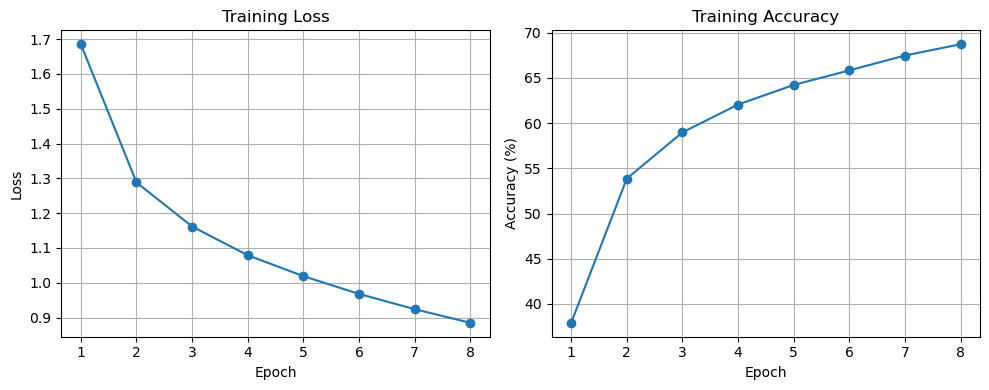

In [ ]:
cnn, classes, trainloader, testloader, history, true_epochs = TrainAndSaveModel(epoch_count=8, batch_size=4, )


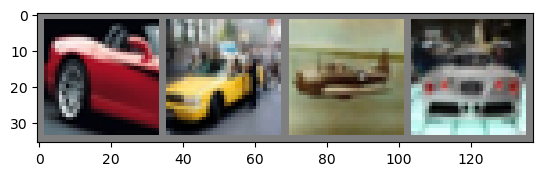

car   car   plane car  


In [18]:
ImgShowGrid(trainloader, classes, 4)

Initializing DataLoaders...
Files already downloaded and verified
Files already downloaded and verified
...classes defined
...criterion and optimizer defined
...about to train the network (with validation and Early stopping)
[Epoch: 1 batch:2000] train batch loss: 2.1792
[Epoch: 1 batch:4000] train batch loss: 1.8416
[Epoch: 1 batch:6000] train batch loss: 1.6943
[Epoch: 1 batch:8000] train batch loss: 1.5922
[Epoch: 1 batch:10000] train batch loss: 1.5371
Epoch 1/8 --> train_loss: 1.7385, train_acc: 35.88% | val_loss: 1.4414, val_acc: 47.40% (best val_loss at epoch 1, 1.4414)
[Epoch: 2 batch:2000] train batch loss: 1.4424
[Epoch: 2 batch:4000] train batch loss: 1.3911
[Epoch: 2 batch:6000] train batch loss: 1.3827
[Epoch: 2 batch:8000] train batch loss: 1.3434
[Epoch: 2 batch:10000] train batch loss: 1.3145
Epoch 2/8 --> train_loss: 1.3653, train_acc: 50.91% | val_loss: 1.2742, val_acc: 54.36% (best val_loss at epoch 2, 1.2742)
[Epoch: 3 batch:2000] train batch loss: 1.2382
[Epoch: 3 

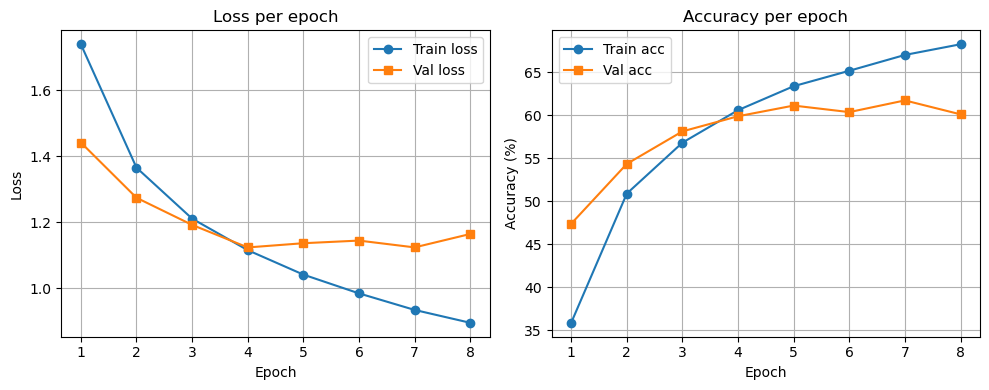

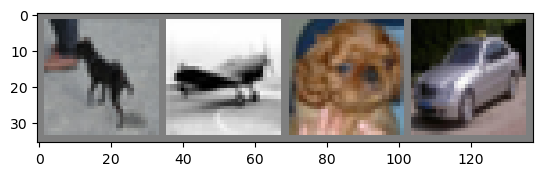

dog   plane dog   car  


In [ ]:
cnn, classes, trainloader, valloader, testloader, history, best_epoch, true_epochs = TrainAndSaveModelWithValidation(nbr_of_epochs=6, batch_size=4, save_path='./cifar_net_best.pth',device=device)

ImgShowGrid(trainloader, classes, 4)

In [20]:
def TestModel(cnn, testloader, classes, device):
    # count predictions for each class
    # notice python syntax: create dictionary where key is classname, and value 0
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # make sure the model is in evaluation mode and not in training mode
    cnn.eval()

    # no gradients needed
    with torch.no_grad():
        for data in testloader:
            # split data to images and labels
            images, labels = data
            # move images and labels to cpu or gpu
            images = images.to(device)
            labels = labels.to(device)

            # calculate outputs
            # because we do not have softmax or those, we use max ourself
            outputs = cnn(images)
            _, predictions = torch.max(outputs, 1)

            # collect the correct predictions for each class
            for label, prediction in zip(labels, predictions):
                # if prediction correct, grow correct_pred with one
                if label == prediction: 
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f"Accuracy of class {classname} is {accuracy:2f}")

    correct = sum(correct_pred.values())
    total = sum(total_pred.values())
    print(f"Network accuracy of total {total} images is {100 * correct // total} ")

    return correct_pred, total_pred

In [21]:
def plot_class_accuracies(correct_pred, total_pred, classes):
    # Compute accuracies in the same order as `classes`
    accuracies = []
    for classname in classes:
        c = correct_pred[classname]
        t = total_pred[classname]
        acc = 100.0 * c / t if t > 0 else 0.0
        accuracies.append(acc)

    # Bar chart
    plt.figure(figsize=(10, 5))
    x = range(len(classes))
    plt.bar(x, accuracies)

    plt.xticks(x, classes, rotation=45)
    plt.ylim(0, 100)
    plt.ylabel("Accuracy (%)")
    plt.title("Per-class accuracy")

    # Optional: show values on top of bars
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 1, f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.grid()
    plt.show()

Accuracy of class plane is 70.600000
Accuracy of class car is 76.000000
Accuracy of class bird is 43.600000
Accuracy of class cat is 53.100000
Accuracy of class deer is 59.100000
Accuracy of class dog is 44.100000
Accuracy of class frog is 60.100000
Accuracy of class horse is 62.500000
Accuracy of class ship is 73.900000
Accuracy of class truck is 68.400000
Network accuracy of total 10000 images is 61 


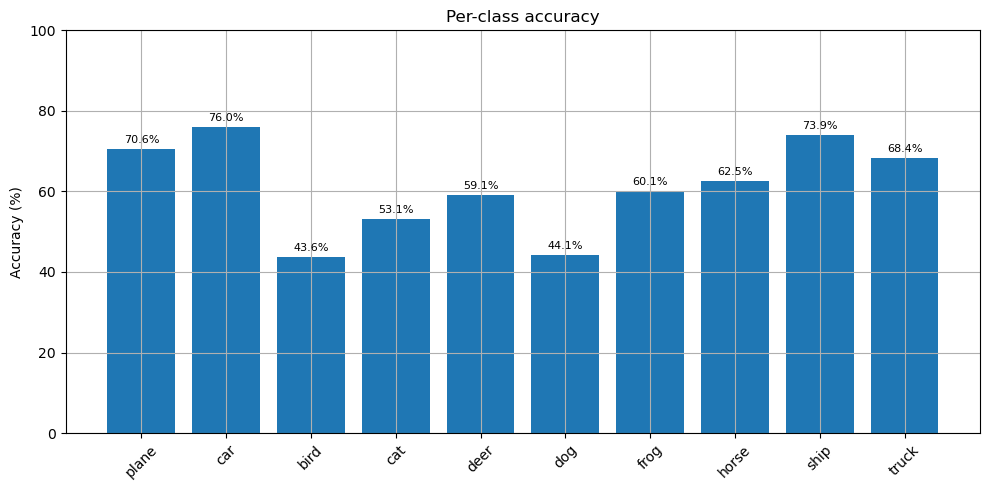

In [22]:
correct_pred, total_pred = TestModel(cnn, testloader, classes, device)
plot_class_accuracies(correct_pred, total_pred, classes)

In [23]:
trainloader